# Game-of-24 GRPO — diagnostics

Loads `eval_rollout.jsonl` produced by `script/run_game24_one.py` and renders
**three** figures, each as a single cell:

1. **D1 · length / diversity** — mean CoT length, length split by correctness,
   and within-puzzle pairwise edit-distance of correct rollouts, all as a
   function of training step (`global_step`).
2. **Accuracy · pass@k** — pass@1, pass@4, pass@8 per eval cycle, computed
   from the JSONL alone via the unbiased combinatorial estimator
   (no extra rollouts needed; each eval cycle already has `num_generations=8`
   samples per puzzle).
3. **R_T · decoding-velocity dynamics** — for a chosen eval cycle
   (`STEP_IDX`), shows (a) one correct + one incorrect rollout's cumulative
   R_t, and (b) the global mean cumulative R_t across many rollouts of each
   class. Use this to inspect how training reshapes the trajectory.

The v_t kernel itself is the vectorized one in `src/velocity.py`.


In [10]:
"""Setup: read eval_rollout.jsonl. No model, no GPU.

`script/run_game24_one.py --score-vt` (default) augments each rollout row
with R_T, R_per_token, and a fixed-grid cumR_resampled. All three figures
below run from those fields plus the original (numbers, correct, n_tokens,
completion, global_step) columns.
"""
import json
from pathlib import Path
from math import comb

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Point this at the output directory produced by script/run_game24_one.py
RUN_DIR  = Path("logs/game24_sweep_exp4/len512/Qwen__Qwen3-4B")
EVAL_LOG = RUN_DIR / "eval_rollout.jsonl"
assert EVAL_LOG.exists(), f"missing {EVAL_LOG}; run script/run_game24_one.py first"

rows = [json.loads(l) for l in EVAL_LOG.read_text().splitlines() if l.strip()]
eval_df = pd.DataFrame(rows)
eval_df["key"] = eval_df["numbers"].apply(lambda x: tuple(sorted(x)))

has_vt = "R_T" in eval_df.columns and eval_df["R_T"].notna().any()
print(f"{len(eval_df)} eval rollouts across "
      f"{eval_df.global_step.nunique()} eval cycles "
      f"(global_step ∈ {sorted(eval_df.global_step.unique().tolist())})")
print(f"R_T fields present: {has_vt}")
eval_df.head(3)

4032 eval rollouts across 7 eval cycles (global_step ∈ [0, 200, 400, 600, 800, 1000, 1200])
R_T fields present: True


,step,idx,numbers,completion,expr,correct,n_tokens,n_cot_tokens,has_answer_marker,has_think_close,split,global_step,R_T,R_per_token,cumR_resampled,key
0,0,0,"[3, 5, 8, 9]","<think>\nOkay, let's see. I have to make 24 us...",,False,512,512,False,False,eval,0,-17.203857,-0.033601,"[11.482315063476562, -7.704045690671359, -5.45...","(3, 5, 8, 9)"
1,0,1,"[3, 5, 8, 9]","<think>\nOkay, let's see. I need to use the nu...",,False,512,512,False,False,eval,0,-16.261566,-0.031761,"[11.482315063476562, -7.704045690671359, -5.71...","(3, 5, 8, 9)"
2,0,2,"[3, 5, 8, 9]","<think>\nOkay, let's see. I need to make 24 us...",,False,512,512,False,False,eval,0,-13.940926,-0.027228,"[11.482315063476562, -7.704045690671359, -5.59...","(3, 5, 8, 9)"


Per eval-cycle structural completeness:
 global_step  pct_truncated  pct_no_think  pct_parsable  pct_correct   mean_len  p90_len  max_len
           0           99.5          99.5           0.5          0.5 511.368056    512.0      512
         200           74.8          74.8          25.2         24.8 477.559028    512.0      512
         400           53.3          53.3          46.7         46.4 431.541667    512.0      512
         600           49.7          49.7          50.3         47.9 419.494792    512.0      512
         800           47.2          46.9          52.8         50.5 403.546875    512.0      512
        1000           43.4          43.1          56.6         53.5 394.618056    512.0      512
        1200           42.9          41.8          57.1         55.0 396.741319    512.0      512

Overall (all eval cycles pooled):
  '####' present     :  41.3%  (1666/4032)
  '</think>' present :  41.6%  (1676/4032)
  parsable (both)    :  41.3%  (1666/4032)
  correct   

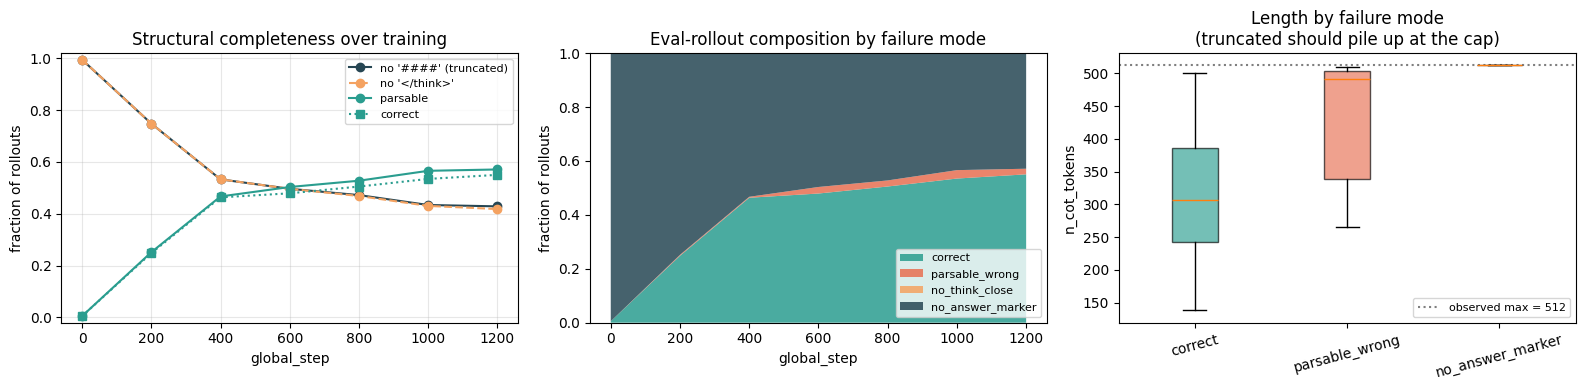

In [11]:
"""Truncation statistics from eval_df.

A rollout is "structurally complete" when both markers are present:
    '</think>' (reasoning closed) AND '####' (parsable answer line).

If either is missing, the response was almost certainly cut off by
max_completion_length (or by the vLLM server's max-model-len, which equals
LEN in the current sweep so the effective generation cap is LEN − prompt_len).

We split incorrect rollouts into:
  - parsable_wrong   : both markers, but the expression is wrong
                       → genuine reasoning error
  - no_answer_marker : '####' missing
                       → almost always truncated mid-CoT
  - no_think_close   : '</think>' missing but '####' somehow present
                       → rare; usually a malformed completion

Reported per eval cycle (`global_step`) so we can see the trend over training.
"""
import inspect
import matplotlib

needed = {"has_answer_marker", "has_think_close"}
assert needed.issubset(eval_df.columns), (
    f"eval_df is missing {needed - set(eval_df.columns)}; "
    "re-run training with the updated RolloutLogger."
)

# matplotlib >=3.9 renamed `labels=` to `tick_labels=`. Pick whichever the
# installed version supports so this cell works on older envs too.
_BOXPLOT_LABEL_KW = (
    "tick_labels"
    if "tick_labels" in inspect.signature(plt.Axes.boxplot).parameters
    else "labels"
)

trunc_df = eval_df.copy()
trunc_df["parsable"] = trunc_df.has_answer_marker & trunc_df.has_think_close

def _bucket(row):
    if row.correct:                       return "correct"
    if not row.has_answer_marker:         return "no_answer_marker"
    if not row.has_think_close:           return "no_think_close"
    return "parsable_wrong"

trunc_df["bucket"] = trunc_df.apply(_bucket, axis=1)

# --- per-step composition -------------------------------------------------
order  = ["correct", "parsable_wrong", "no_think_close", "no_answer_marker"]
colors = {"correct": "#2a9d8f", "parsable_wrong": "#e76f51",
          "no_think_close": "#f4a261", "no_answer_marker": "#264653"}

comp = (trunc_df.groupby(["global_step", "bucket"]).size()
                .unstack(fill_value=0)
                .reindex(columns=order, fill_value=0))
comp_frac = comp.div(comp.sum(axis=1), axis=0)

# --- per-step length stats split by truncation status --------------------
len_col = "n_cot_tokens" if "n_cot_tokens" in trunc_df.columns else "n_tokens"
by_step = trunc_df.groupby("global_step").agg(
    pct_truncated   =("has_answer_marker", lambda s: 1.0 - s.mean()),
    pct_no_think    =("has_think_close",   lambda s: 1.0 - s.mean()),
    pct_parsable    =("parsable",          "mean"),
    pct_correct     =("correct",           "mean"),
    mean_len        =(len_col,             "mean"),
    p90_len         =(len_col,             lambda s: float(np.percentile(s, 90))),
    max_len         =(len_col,             "max"),
).reset_index()

print("Per eval-cycle structural completeness:")
print(by_step.assign(
    pct_truncated=lambda d: (d.pct_truncated * 100).round(1),
    pct_no_think =lambda d: (d.pct_no_think  * 100).round(1),
    pct_parsable =lambda d: (d.pct_parsable  * 100).round(1),
    pct_correct  =lambda d: (d.pct_correct   * 100).round(1),
).to_string(index=False))

# --- overall, and within-incorrect breakdown -----------------------------
def _pct(mask): return f"{mask.mean()*100:5.1f}%  ({int(mask.sum())}/{len(mask)})"

print("\nOverall (all eval cycles pooled):")
print(f"  '####' present     : {_pct(trunc_df.has_answer_marker)}")
print(f"  '</think>' present : {_pct(trunc_df.has_think_close)}")
print(f"  parsable (both)    : {_pct(trunc_df.parsable)}")
print(f"  correct            : {_pct(trunc_df.correct)}")

inc = trunc_df[~trunc_df.correct]
if len(inc):
    print(f"\nAmong {len(inc)} incorrect eval rollouts:")
    print(f"  no_answer_marker (truncated)   : {_pct(~inc.has_answer_marker)}")
    print(f"  no_think_close                 : {_pct(~inc.has_think_close & inc.has_answer_marker)}")
    print(f"  parsable_wrong (real error)    : {_pct(inc.parsable)}")

# --- figure: 3 panels -----------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# (a) trend lines over training
axes[0].plot(by_step.global_step, by_step.pct_truncated, label="no '####' (truncated)",
             color=colors["no_answer_marker"], marker="o")
axes[0].plot(by_step.global_step, by_step.pct_no_think, label="no '</think>'",
             color=colors["no_think_close"], marker="o", linestyle="--")
axes[0].plot(by_step.global_step, by_step.pct_parsable, label="parsable",
             color="#2a9d8f", marker="o")
axes[0].plot(by_step.global_step, by_step.pct_correct, label="correct",
             color="#2a9d8f", marker="s", linestyle=":")
axes[0].set(xlabel="global_step", ylabel="fraction of rollouts",
            title="Structural completeness over training", ylim=(-0.02, 1.02))
axes[0].grid(alpha=0.3); axes[0].legend(fontsize=8)

# (b) stacked composition by failure mode
axes[1].stackplot(comp_frac.index,
                  *[comp_frac[c] for c in order],
                  labels=order,
                  colors=[colors[c] for c in order], alpha=0.85)
axes[1].set(xlabel="global_step", ylabel="fraction of rollouts",
            title="Eval-rollout composition by failure mode", ylim=(0, 1))
axes[1].legend(loc="lower right", fontsize=8)

# (c) length by bucket — truncated rollouts should pile up at the cap
data, labels = [], []
for b in order:
    vals = trunc_df.loc[trunc_df.bucket == b, len_col].values
    if len(vals):
        data.append(vals); labels.append(b)
parts = axes[2].boxplot(data, patch_artist=True, showfliers=False,
                        **{_BOXPLOT_LABEL_KW: labels})
for patch, lbl in zip(parts["boxes"], labels):
    patch.set_facecolor(colors[lbl]); patch.set_alpha(0.65)
cap = int(trunc_df[len_col].max())
axes[2].axhline(cap, color="k", linestyle=":", alpha=0.5,
                label=f"observed max = {cap}")
axes[2].set(ylabel=len_col,
            title="Length by failure mode\n(truncated should pile up at the cap)")
axes[2].tick_params(axis="x", rotation=15)
axes[2].legend(fontsize=8)

fig.tight_layout(); plt.show()

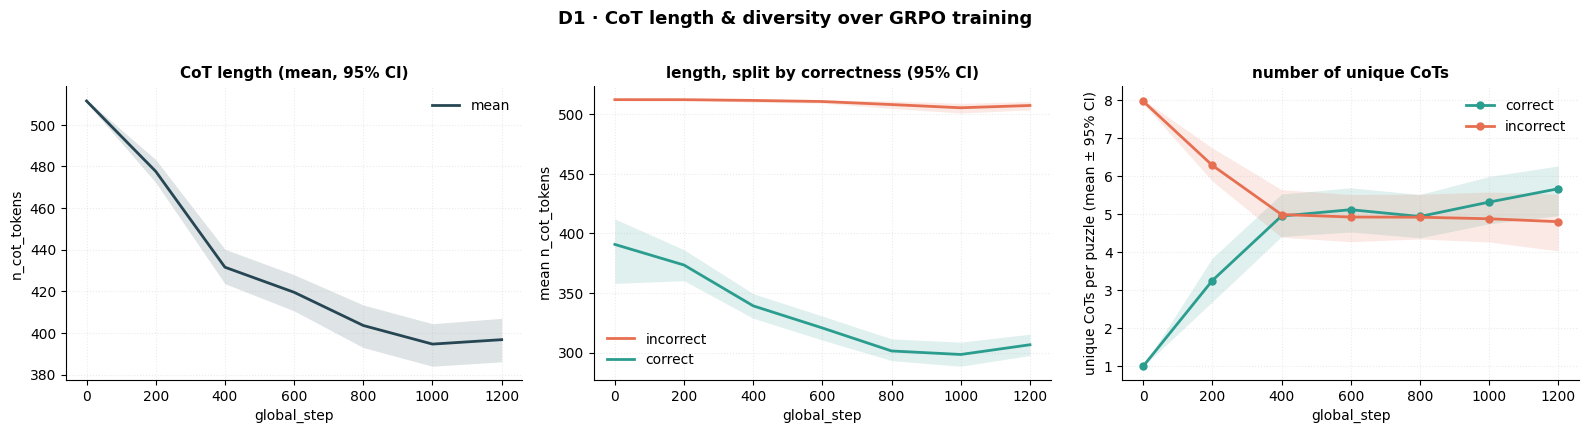

In [12]:
"""Figure 1 · D1: CoT length & diversity over GRPO training (step 0 → 1200).

Panels:
  1. Mean CoT length per step (95% bootstrap CI ribbon).
  2. Mean CoT length split by correctness (95% bootstrap CI ribbons).
  3. Mean number of unique CoTs per puzzle, split by correctness.
     Uniqueness = whitespace-normalized exact-string match. For this
     dataset uniqueness equals total count (every CoT byte-distinct
     post-whitespace), so the y-axis is effectively "rollouts of class X
     per puzzle". A future swap to AST-canonicalized `expr` would convert
     this to a true semantic-collapse signal.
"""
len_col = "n_cot_tokens" if "n_cot_tokens" in eval_df.columns else "n_tokens"

# --- palette (muted, print-friendly) ---------------------------------------
C_CORRECT   = "#2a9d8f"
C_INCORRECT = "#e76f51"
C_MEAN      = "#264653"

# --- bootstrap helpers ------------------------------------------------------
def _boot_ci(values, fn, n_boot=300, seed=0):
    v = np.asarray(values, dtype=float)
    if len(v) < 2:
        c = float(fn(v)) if len(v) else float("nan")
        return c, c
    rng = np.random.default_rng(seed)
    boots = np.array([fn(rng.choice(v, size=len(v), replace=True))
                      for _ in range(n_boot)])
    return float(np.percentile(boots, 2.5)), float(np.percentile(boots, 97.5))

def _per_step(df, value_col, fn):
    rows = []
    for step, g in df.groupby("global_step"):
        v = g[value_col].values
        lo, hi = _boot_ci(v, fn)
        rows.append({"step": step, "val": float(fn(v)), "lo": lo, "hi": hi})
    return pd.DataFrame(rows).sort_values("step")

# --- aggregations -----------------------------------------------------------
mean_df = _per_step(eval_df, len_col, np.mean)
corr_dfs = {bool(k): _per_step(g, len_col, np.mean)
            for k, g in eval_df.groupby("correct")}

# --- panel 3: per-puzzle unique-CoT count, split by correctness ------------
def _norm(s: str) -> str:
    return " ".join(s.split())

rows = []
for (step, key, correct), g in eval_df.groupby(["global_step", "key", "correct"]):
    rows.append({"step": step, "correct": bool(correct),
                 "n_unique": len({_norm(c) for c in g.completion})})
udf = pd.DataFrame(rows)

uniq_dfs = {
    bool(is_corr): _per_step(g.rename(columns={"step": "global_step"}),
                             "n_unique", np.mean)
    for is_corr, g in udf.groupby("correct")
}

# --- plotting ---------------------------------------------------------------
with plt.rc_context({
    "axes.spines.top":   False, "axes.spines.right": False,
    "axes.grid":         True,  "grid.alpha": 0.25, "grid.linestyle": ":",
    "axes.titleweight":  "bold", "axes.titlesize": 11,
    "axes.labelsize":    10,    "legend.frameon": False,
}):
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.2), sharex=True)

    # ---- panel 1: mean length ---------------------------------------------
    ax = axes[0]
    ax.plot(mean_df.step, mean_df.val, color=C_MEAN, lw=2, label="mean")
    ax.fill_between(mean_df.step, mean_df.lo, mean_df.hi,
                    color=C_MEAN, alpha=0.15, linewidth=0)
    ax.set(xlabel="global_step", ylabel=len_col,
           title="CoT length (mean, 95% CI)")
    ax.legend(loc="best")

    # ---- panel 2: length split by correctness -----------------------------
    ax = axes[1]
    for is_corr, df in corr_dfs.items():
        c = C_CORRECT if is_corr else C_INCORRECT
        lbl = "correct" if is_corr else "incorrect"
        ax.plot(df.step, df.val, color=c, lw=2, label=lbl)
        ax.fill_between(df.step, df.lo, df.hi,
                        color=c, alpha=0.15, linewidth=0)
    ax.set(xlabel="global_step", ylabel=f"mean {len_col}",
           title="length, split by correctness (95% CI)")
    ax.legend(loc="best")

    # ---- panel 3: unique CoTs per puzzle, split by correctness ------------
    ax = axes[2]
    for is_corr in (True, False):
        c   = C_CORRECT if is_corr else C_INCORRECT
        lbl = "correct" if is_corr else "incorrect"
        df  = uniq_dfs[is_corr]
        ax.plot(df.step, df.val, color=c, lw=2, marker="o", ms=5, label=lbl)
        ax.fill_between(df.step, df.lo, df.hi,
                        color=c, alpha=0.15, linewidth=0)
    ax.set(xlabel="global_step",
           ylabel="unique CoTs per puzzle (mean ± 95% CI)",
           title="number of unique CoTs")
    ax.legend(loc="best")

    fig.suptitle("D1 · CoT length & diversity over GRPO training",
                 fontsize=13, fontweight="bold", y=1.02)
    fig.tight_layout()
    plt.show()


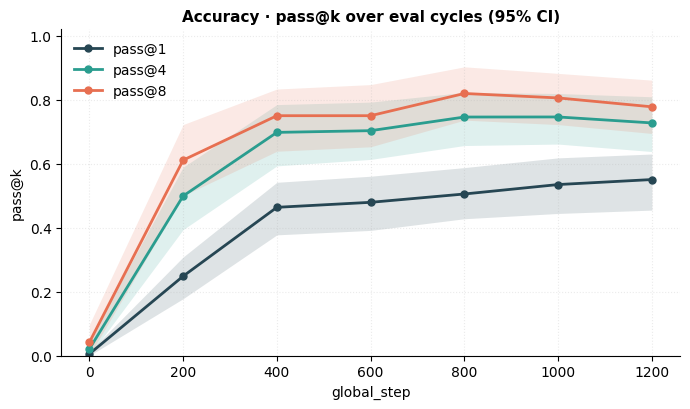

k                1      4      8
global_step                     
0            0.005  0.021  0.042
200          0.248  0.499  0.611
400          0.464  0.698  0.750
600          0.479  0.703  0.750
800          0.505  0.746  0.819
1000         0.535  0.746  0.806
1200         0.550  0.727  0.778


In [13]:
"""Figure 2 · pass@1, pass@4, pass@8 over GRPO training (95% bootstrap CI).

Each (eval cycle, puzzle) cell has `num_generations` rollouts (=8 by
default). Per-puzzle unbiased estimator:
    pass@k = 1 - C(n-c, k) / C(n, k),  n = #rollouts, c = #correct
Cycle-level point = mean across puzzles; CI ribbon = 95% bootstrap over
puzzles (300 resamples). No extra forward passes needed.
"""
KS = (1, 4, 8)

# --- palette: distinct hues per k ------------------------------------------
C_K = {1: "#264653", 4: "#2a9d8f", 8: "#e76f51"}

def pass_at_k(c: int, n: int, k: int) -> float:
    if n - c < k:
        return 1.0
    return 1.0 - comb(n - c, k) / comb(n, k)

# --- per-(step, puzzle, k) pass@k ------------------------------------------
rows = []
for (gs, key), g in eval_df.groupby(["global_step", "key"]):
    n = len(g); c = int(g.correct.sum())
    for k in KS:
        if k > n:
            continue
        rows.append({"global_step": gs, "key": key, "k": k,
                     "pass": pass_at_k(c, n, k)})
pak_long = pd.DataFrame(rows)

# --- per-step mean + 95% bootstrap CI over puzzles -------------------------
def _boot_ci_mean(values, n_boot=300, seed=0):
    v = np.asarray(values, dtype=float)
    if len(v) < 2:
        c = float(v.mean()) if len(v) else float("nan")
        return c, c
    rng = np.random.default_rng(seed)
    boots = np.array([rng.choice(v, size=len(v), replace=True).mean()
                      for _ in range(n_boot)])
    return float(np.percentile(boots, 2.5)), float(np.percentile(boots, 97.5))

pak_summary = []
for (step, k), g in pak_long.groupby(["global_step", "k"]):
    lo, hi = _boot_ci_mean(g["pass"].values)
    pak_summary.append({"step": step, "k": k,
                        "val": float(g["pass"].mean()), "lo": lo, "hi": hi})
pak_df = pd.DataFrame(pak_summary).sort_values(["k", "step"])

# --- plotting ---------------------------------------------------------------
with plt.rc_context({
    "axes.spines.top":   False, "axes.spines.right": False,
    "axes.grid":         True,  "grid.alpha": 0.25, "grid.linestyle": ":",
    "axes.titleweight":  "bold", "axes.titlesize": 11,
    "axes.labelsize":    10,    "legend.frameon": False,
}):
    fig, ax = plt.subplots(figsize=(7, 4.2))
    for k in KS:
        sub = pak_df[pak_df.k == k]
        if sub.empty:
            continue
        c = C_K[k]
        ax.plot(sub.step, sub.val, color=c, lw=2, marker="o", ms=5,
                label=f"pass@{k}")
        ax.fill_between(sub.step, sub.lo, sub.hi,
                        color=c, alpha=0.15, linewidth=0)
    ax.set(xlabel="global_step", ylabel="pass@k", ylim=(0, 1.02),
           title="Accuracy · pass@k over eval cycles (95% CI)")
    ax.legend(loc="best")
    fig.tight_layout()
    plt.show()

print((pak_df.pivot(index="step", columns="k", values="val")
             .round(3)
             .rename_axis(index="global_step")))


Puzzles with ≥1 canonical solution: 72 / 72
Puzzles where the model EVER found ≥1 solution: 63 / 72
|S(p)| stats: min=4, max=228, mean=48.22
Rollouts per (step,puzzle): mode=8

Per-cycle:  # unique rollouts / # rollouts
 step   val    lo    hi  n_puzzles
    0 0.005 0.000 0.012         72
  200 0.127 0.097 0.156         72
  400 0.240 0.197 0.283         72
  600 0.227 0.183 0.268         72
  800 0.240 0.202 0.281         72
 1000 0.243 0.196 0.287         72
 1200 0.243 0.199 0.288         72

Cumulative:  # found solutions / # solutions   (over s' ≤ s)
 step   val    lo    hi  n_puzzles
    0 0.004 0.000 0.012         72
  200 0.036 0.022 0.055         72
  400 0.073 0.055 0.093         72
  600 0.091 0.072 0.111         72
  800 0.103 0.081 0.127         72
 1000 0.109 0.086 0.132         72
 1200 0.118 0.091 0.140         72

Novel-fraction:  # novel solutions / # ever-found  (per cycle)
 step   val    lo    hi  n_puzzles
    0 0.016 0.000 0.037         63
  200 0.254 0.194 0.324 

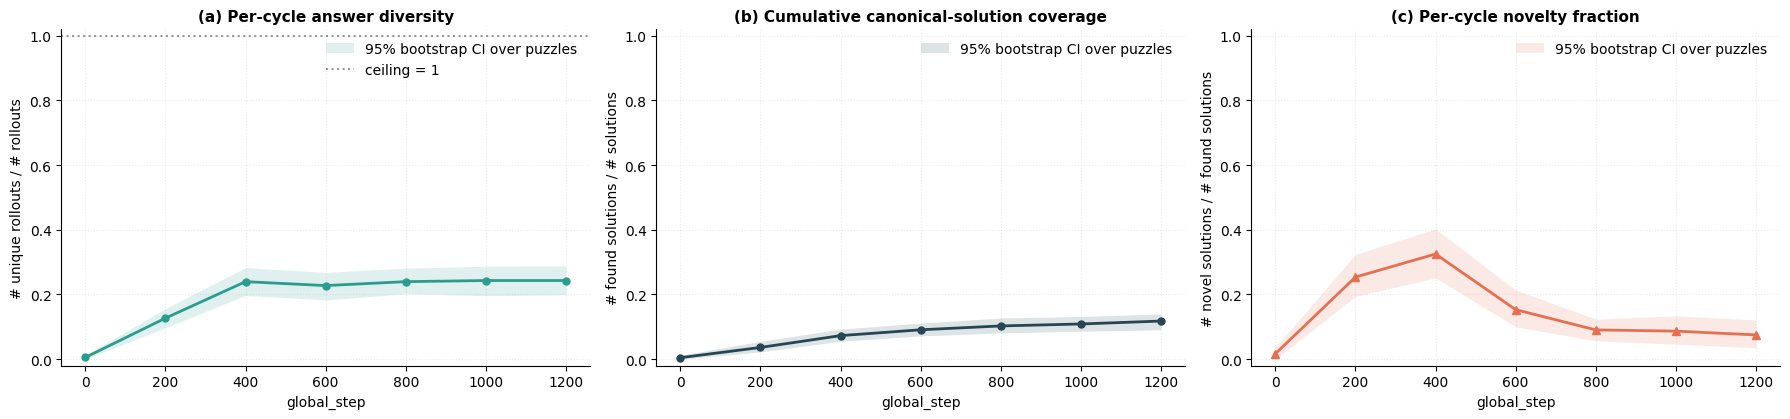

In [15]:
"""Figure · Solution coverage dynamics (3 panels).

See ``src.velo_viz.plot_solution_coverage_dynamics`` for the full math
(per-cycle diversity, cumulative canonical-solution coverage, per-cycle
novelty fraction with denom = ever-found).
"""
from src.velo_viz import plot_solution_coverage_dynamics

fig, axes, cov_info = plot_solution_coverage_dynamics(eval_df)
plt.show()


Tracing puzzle  numbers=[1, 3, 3, 5]  (puzzle #11 of 72)
|S(p)| = 66, G = 8, 7 eval cycles, 56 rollouts total.
Distinct expressions (excl. no-expr): 6  (6 verifier-correct, of which 6 also ∈ enumerate_solutions; 0 verifier-wrong)

Lane summary (birth-ordered):
  ✓ ★ born@step=400  (400:1 1200:1)   (3 + 3) * (5 - 1)
  ✓ ★ born@step=400  (400:1)   (3 + 5) * (3 / 1)
  ✓ ★ born@step=400  (400:4 600:4 800:4 1000:4 1200:5)   (5 - 1) * (3 + 3)
  ✓ ★ born@step=600  (600:2 800:2)   3*(5 + (3/1))
  ✓ ★ born@step=600  (600:1)   3*(5+3)*1
  ✓ ★ born@step=800  (800:1)   3*(5*1 + 3)

  ✗  truncated / no expr   (0:8 200:8 400:2 600:1 800:1 1000:4 1200:2)


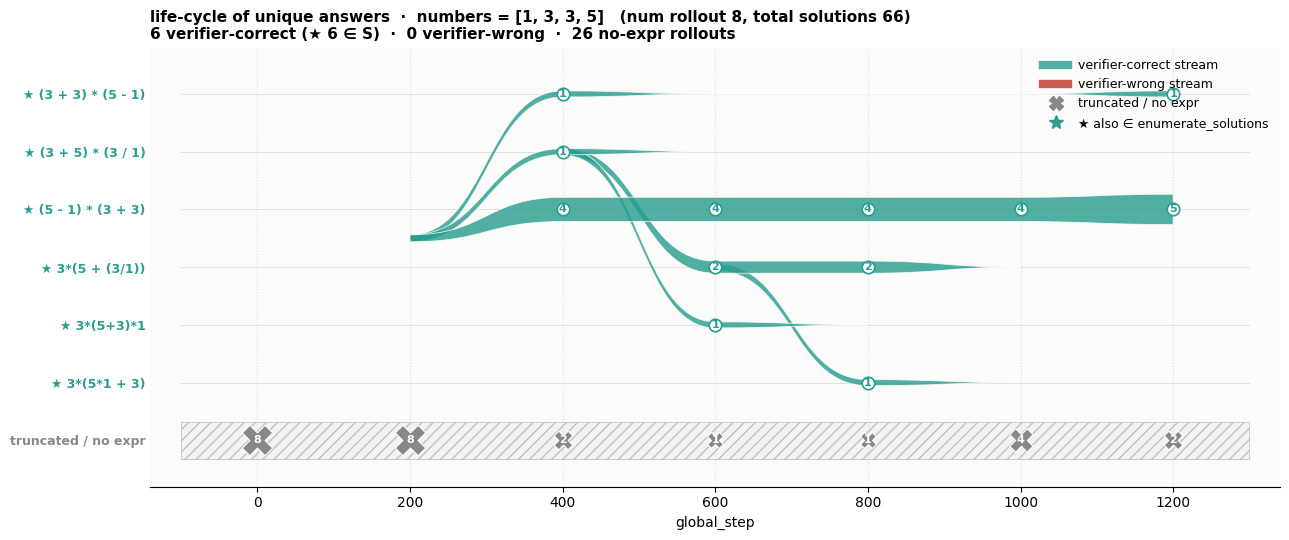

In [16]:
from src.velo_viz import plot_lifecycle_river

# ====== CONFIG ============================================================
IDX     = 11
NUMBERS = None          # e.g. (1, 1, 3, 8) — overrides IDX if set
# ==========================================================================

fig, ax, info = plot_lifecycle_river(
    eval_df,
    idx=IDX,
    numbers=NUMBERS,
)
plt.show()


Median pairwise LCP across all (step, key, pair) = 125.0 chars  →  PREFIX_LEN = 120

Computed LCP for 14,112 pairs across 7 eval cycles.

Within-puzzle top-k 120-char prefix coverage (mean across 72 puzzles):
 step  top1  top2  top3  top4  top5
    0 0.661 0.830 0.929 0.983 0.998
  200 0.774 0.913 0.979 0.997 1.000
  400 0.658 0.880 0.962 0.995 0.998
  600 0.727 0.901 0.976 1.000 1.000
  800 0.738 0.901 0.970 0.993 0.998
 1000 0.705 0.877 0.957 0.993 1.000
 1200 0.698 0.873 0.953 0.990 0.997

=== Representative 120-char prefixes at step 1200 ===
(top-1 share = fraction of the 8 rollouts that share the most-common prefix)

numbers=[2, 2, 2, 8]  top-1 share = 100%  (1 unique prefixes)
  [8/8]  "<think>\\nOkay, let's see. I need to use the numbers 2, 2, 2, 8 exactly once with arithmetic operations to get 24. Hmm. Le"

numbers=[2, 3, 8, 8]  top-1 share = 100%  (1 unique prefixes)
  [8/8]  "<think>\\nOkay, let's see. I need to use the numbers 2, 3, 8, 8 exactly once with arithmetic operatio

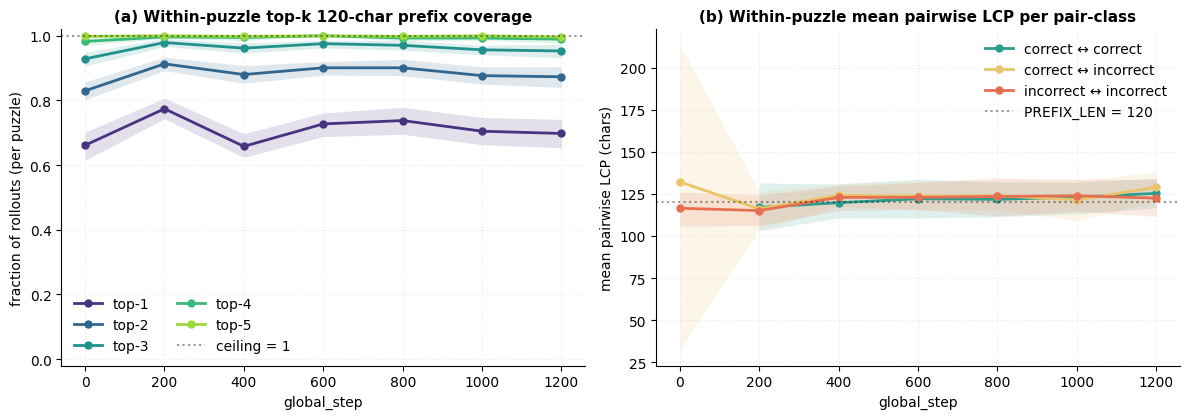

In [21]:
"""Claim 5a · Within-puzzle prefix sharing across rollouts.

See `src.velo_viz.plot_prefix_sharing_dynamics` for the full math
(per-pair-class mean LCP with data-driven PREFIX_LEN, within-puzzle top-k
prefix coverage, 95% bootstrap CIs over puzzles).
"""
from src.velo_viz import plot_prefix_sharing_dynamics

fig, axes, info = plot_prefix_sharing_dynamics(eval_df)
plt.show()


step=1200  rollouts: correct=317  incorrect=259  puzzles total=72  with-both=38


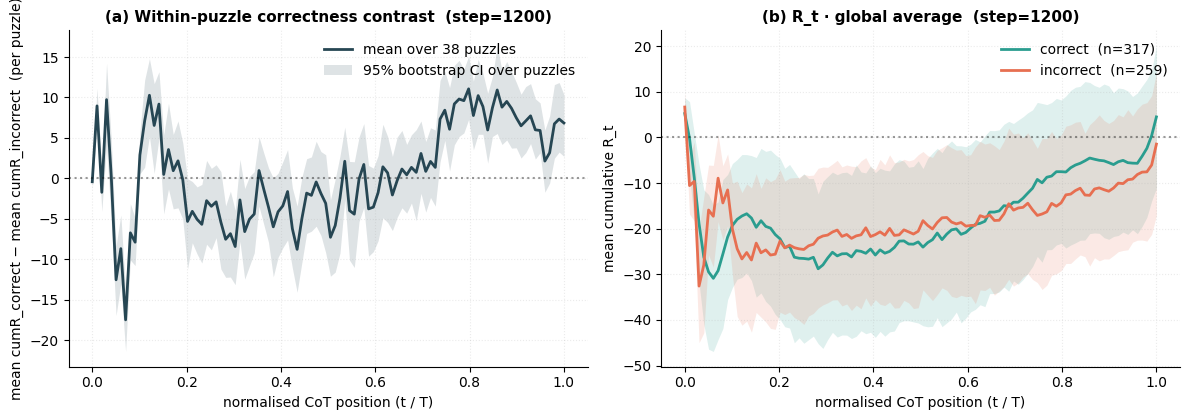

In [ ]:
"""Figure 3 · R_t decoding-velocity dynamics at step 1200.

See `src.velo_viz.plot_R_t_correctness_dynamics` for the full math
(per-reference → scalar collapse, within-puzzle correctness contrast with
95% bootstrap CI, global ±1σ marginal split).
"""
from src.velo_viz import plot_R_t_correctness_dynamics

fig, axes, info = plot_R_t_correctness_dynamics(RUN_DIR / "eval_rollout_vt.jsonl")
plt.show()
